<a href="https://colab.research.google.com/github/strzelnat/Charts_exercisers/blob/main/basics/lesson6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

np.random.seed(42)
sns.set(font_scale = 1.3)

In [60]:
from sklearn.datasets import load_iris

raw_data = load_iris()
raw_data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [61]:
all_data = raw_data.copy()

data = all_data['data']
target = all_data['target']

In [62]:
print(f'{data[:4]}\n')
print(f'{target[:4]}')

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]]

[0 0 0 0]


In [63]:
all_data['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [64]:
df = pd.DataFrame(data = np.c_[data, target], columns = all_data['feature_names'] + ['class'])

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   class              150 non-null    float64
dtypes: float64(5)
memory usage: 6.0 KB


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5
class,150.0,1.000000,0.819232,0.0,0.0,1.00,2.0,2.0


In [65]:
df['class'].value_counts()

,count
class,
0.0,50
1.0,50
2.0,50


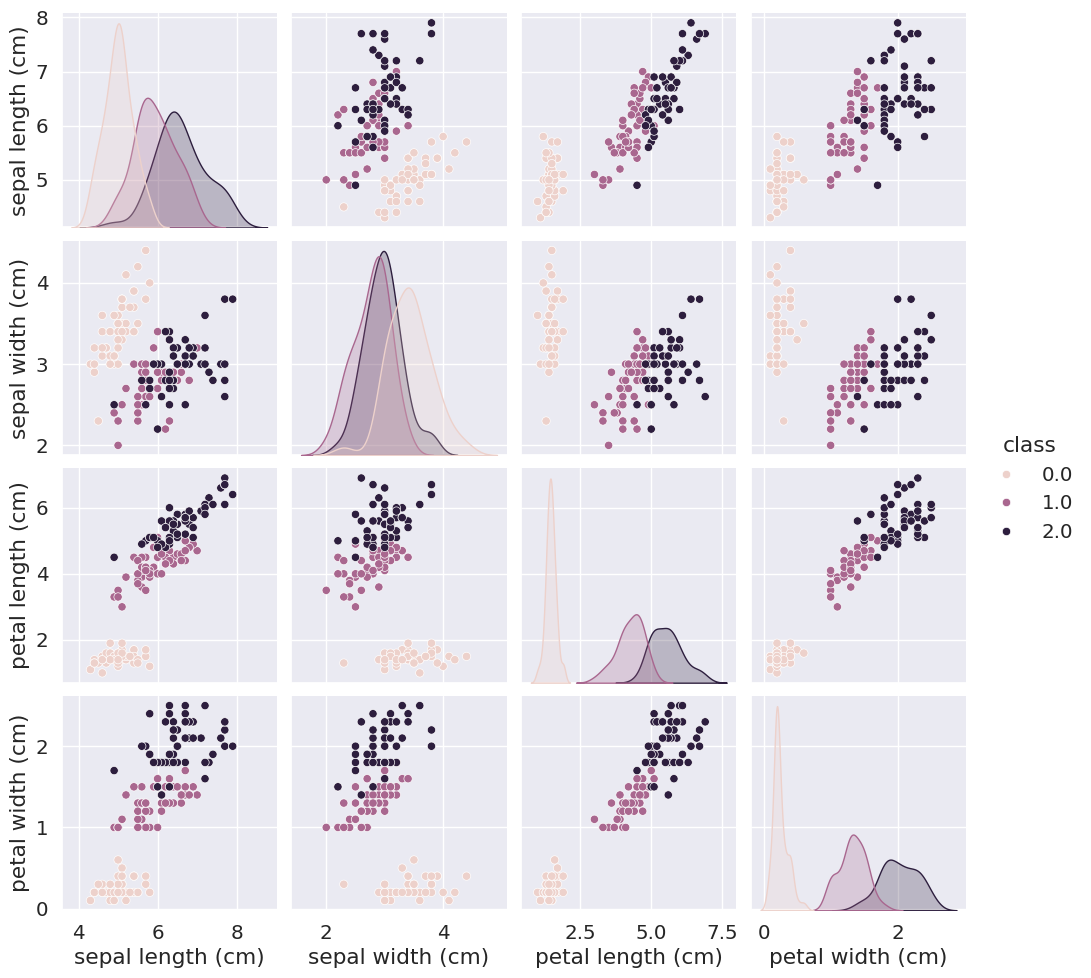

In [66]:
_ = sns.pairplot(df, hue = 'class')

In [18]:
df.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
class,0.782561,-0.426658,0.949035,0.956547,1.000000


In [68]:
data = data[:, :2]

In [69]:
print(f'data : {data.shape}')
print(f'target : {target.shape}')

data : (150, 2)
target : (150,)


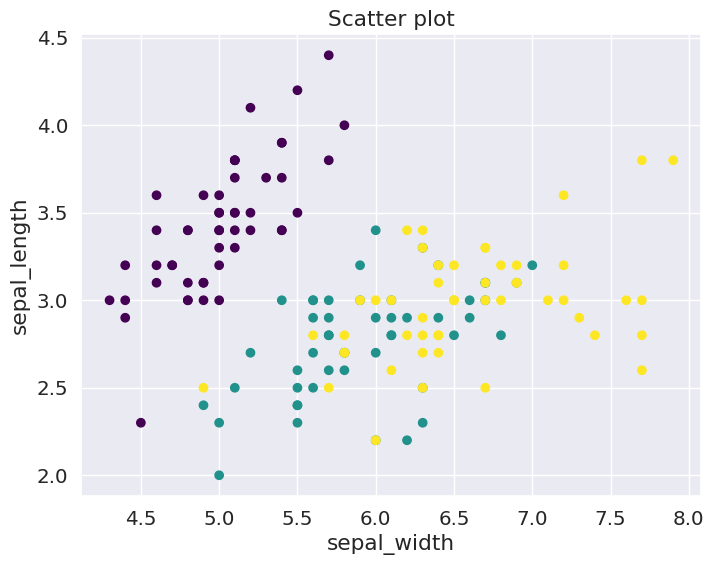

In [70]:
plt.figure(figsize=(8,6))
plt.scatter(data[:, 0], data[:, 1], c = target, cmap = 'viridis')
plt.title('Scatter plot')
plt.xlabel('sepal_width')
plt.ylabel('sepal_length')
plt.show()

In [71]:
df = pd.DataFrame(data =np.c_[data, target], columns = ['sepal_length', 'sepal_width', 'class'])

In [73]:
px.scatter(df, x = 'sepal_length', y = 'sepal_width', color = 'class')

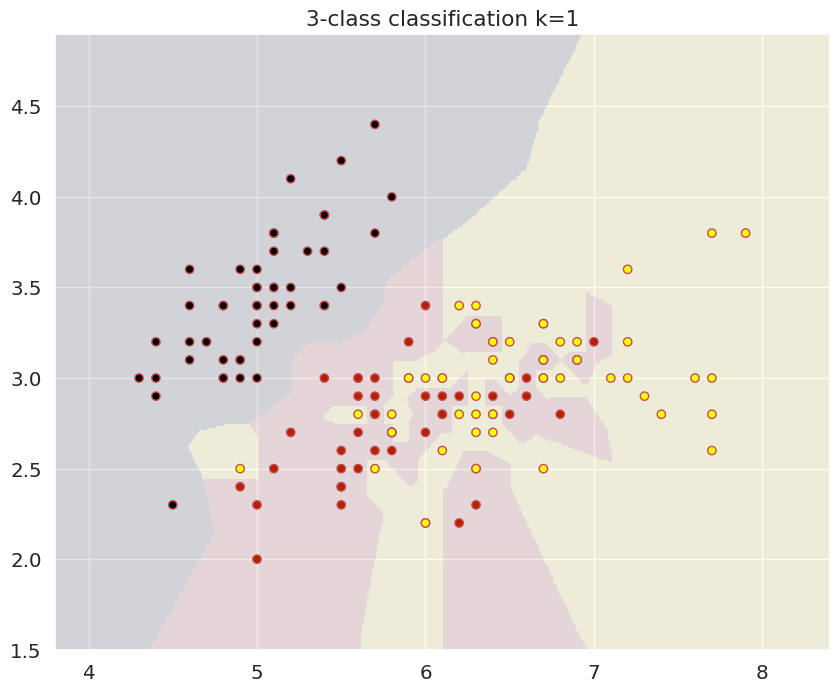

In [83]:
from sklearn.neighbors import KNeighborsClassifier

def plot_class_neighbours(k = 1):

  classifier  = KNeighborsClassifier(n_neighbors = k)
  classifier.fit(data, target)

  x_min, x_max = data[:,0].min() - 0.5, data[:,0].max() + 0.5
  y_min, y_max = data[:,1].min() - 0.5, data[:,1].max() + 0.5

  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
  mesh = np.c_[xx.ravel(), yy.ravel()]
  Z = classifier.predict(mesh)
  Z = Z.reshape(xx.shape)

  plt.figure(figsize=(10, 8))
  plt.pcolormesh(xx, yy, Z, cmap='gnuplot', alpha=0.1)
  plt.scatter(data[:, 0], data[:, 1], c=target, cmap='gnuplot', edgecolors='r')
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())
  plt.title(f'3-class classification k={k}')
  plt.show()

plot_class_neighbours()

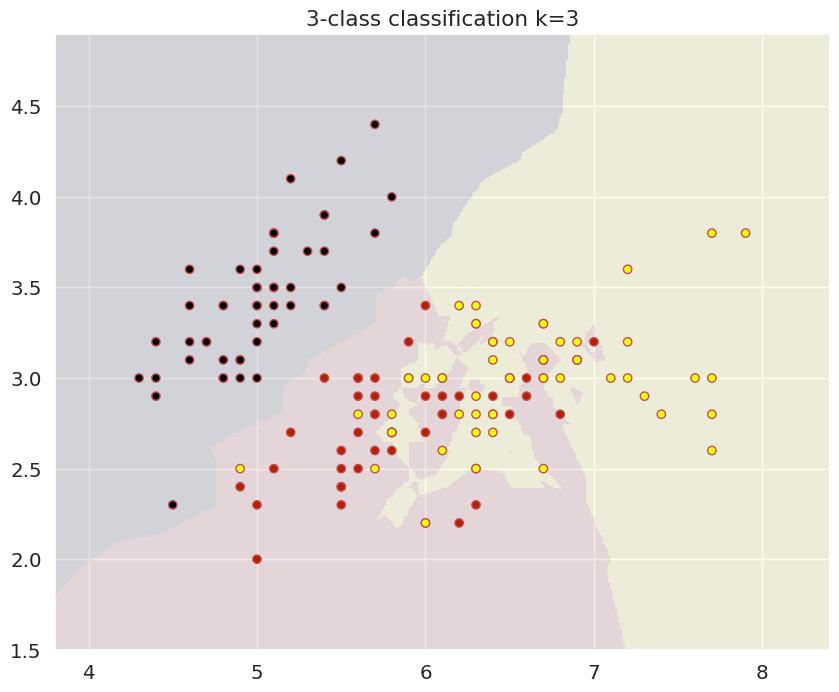

In [84]:
  plot_class_neighbours(3)

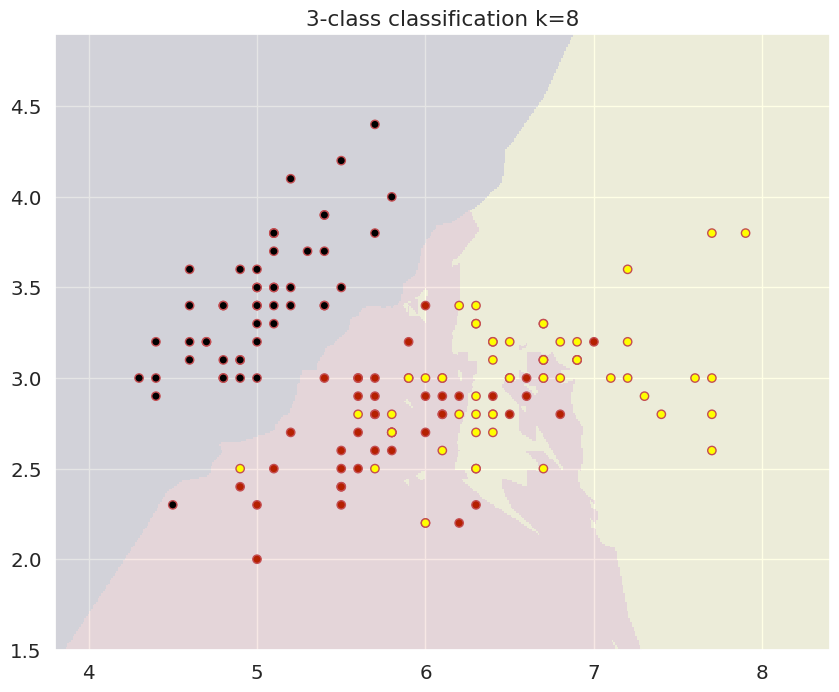

In [85]:
plot_class_neighbours(8)